In [1]:
# ============================================
# Decision Tree Classifier — Iris Flower Classification
# Splits data based on feature thresholds to
# classify flowers into one of 3 species
# ============================================

import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

# Load cleaned data
df = pd.read_csv('../data/processed/iris_cleaned.csv')

# Features and target
X = df[['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']]
y = df['Species']

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Build Decision Tree model
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

print("Decision Tree model trained successfully!")

Decision Tree model trained successfully!


In [2]:
# Load KNN model to compare side by side
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

# Predictions from both models
y_pred_dt = dt.predict(X_test)
y_pred_knn = knn.predict(X_test)

# Compare accuracies
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))
print("KNN Accuracy:          ", accuracy_score(y_test, y_pred_knn))

Decision Tree Accuracy: 1.0
KNN Accuracy:           1.0


In [3]:
# Test with same 5 inputs as Day 8
test_inputs = pd.DataFrame([
    [5.1, 3.5, 1.4, 0.2],
    [6.2, 2.9, 4.3, 1.3],
    [7.3, 2.9, 6.3, 1.8],
    [4.9, 3.0, 1.4, 0.2],
    [6.5, 3.0, 5.5, 1.8],
], columns=['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm'])

for i in range(len(test_inputs)):
    row = test_inputs.iloc[[i]]
    knn_pred = knn.predict(row)[0]
    dt_pred = dt.predict(row)[0]
    match = "✅" if knn_pred == dt_pred else "❌"
    print(f"Test {i+1}: KNN={knn_pred} | DT={dt_pred} {match}")

Test 1: KNN=Iris-setosa | DT=Iris-setosa ✅
Test 2: KNN=Iris-versicolor | DT=Iris-versicolor ✅
Test 3: KNN=Iris-virginica | DT=Iris-virginica ✅
Test 4: KNN=Iris-setosa | DT=Iris-setosa ✅
Test 5: KNN=Iris-virginica | DT=Iris-virginica ✅


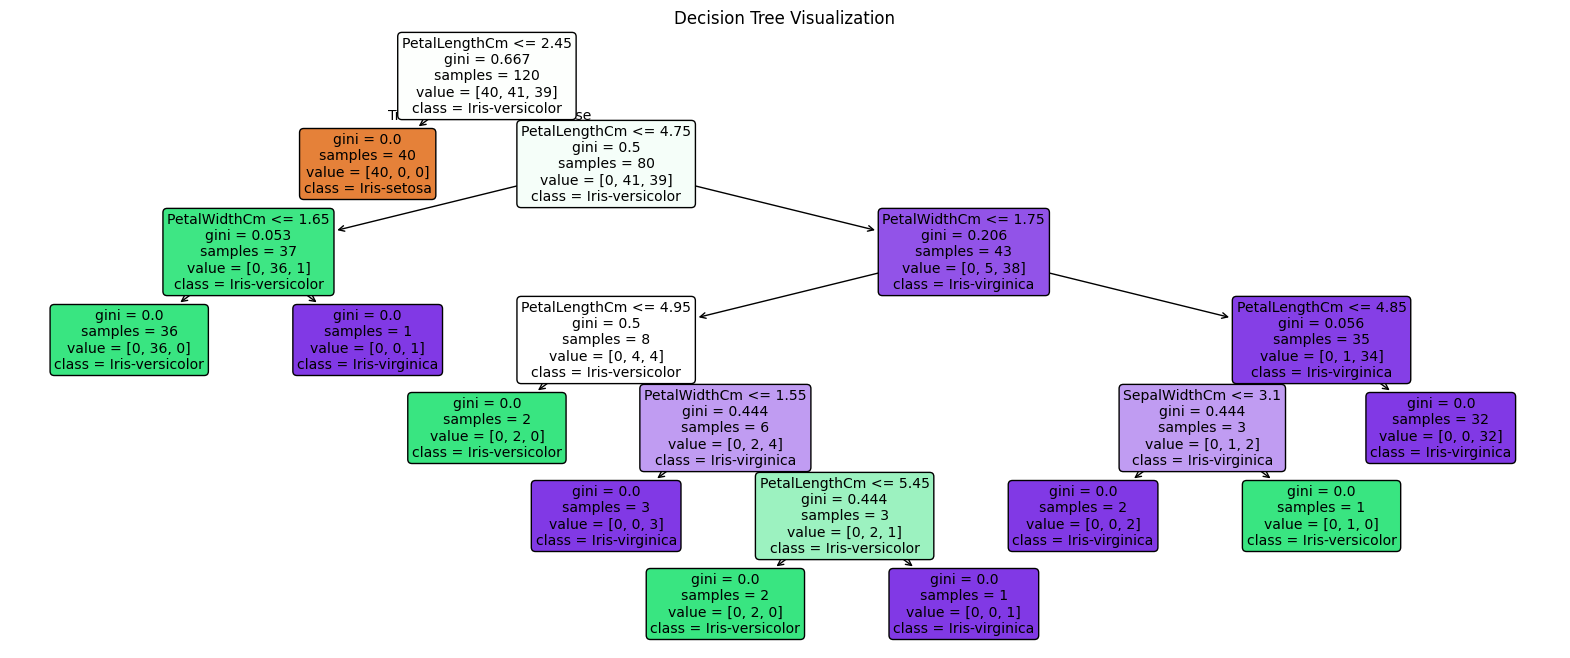

Decision tree saved to docs!


In [4]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(20, 8))
plot_tree(dt, feature_names=X.columns, 
          class_names=dt.classes_, 
          filled=True, rounded=True)
plt.title("Decision Tree Visualization")
plt.savefig('../docs/decision_tree.png', bbox_inches='tight', dpi=150)
plt.show()
print("Decision tree saved to docs!")